<a href="https://colab.research.google.com/github/l3wandowskyy/Pricing-Footballers-Master/blob/main/preditict_value_footballer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Cleaning

In [413]:
import pandas as pd

# Import data
players = pd.read_excel('players_data_set.xlsx')

# Count rows and columns
players.shape

(7845, 30)

In [414]:
# Count the empty values in each column
players.isnull().sum()

,0
Player ID,0
Player Name,0
Nationality,0
Team Title,0
Team Position in League,0
Matches,0
League,0
UEFA league ranking,0
Position,0
Birth Date,0


In [415]:
# Delete empty values in Market Value and Goal Contribution Share
players = players.dropna(subset=['Market Value', 'Goal Contribution Share'])

In [416]:
# Fill in the blank values in the height and foot columns
players['Height'] = players['Height'].fillna(players['Height'].mean())
most_common_foot = players['Foot'].mode()[0]
players['Foot'] = players['Foot'].fillna(most_common_foot)

# Count the empty values in each column
players.isnull().sum()

,0
Player ID,0
Player Name,0
Nationality,0
Team Title,0
Team Position in League,0
Matches,0
League,0
UEFA league ranking,0
Position,0
Birth Date,0


In [417]:
# Check the data types of each column
players.dtypes

,0
Player ID,int64
Player Name,object
Nationality,object
Team Title,object
Team Position in League,object
Matches,int64
League,object
UEFA league ranking,int64
Position,object
Birth Date,object


In [418]:
# Change the data type for categorical columns
players["Nationality"] = players["Nationality"].astype("str")
players["Team Title"] = players["Team Title"].astype("str")
players["League"] = players["League"].astype("str")
players["Position"] = players["Position"].astype("str")
players["Foot"] = players["Foot"].astype("str")
players["Season"] = players["Season"].astype("str")

# Convert date columns to datetime format (dd.mm.yyyy)
players["Birth Date"] = pd.to_datetime(players["Birth Date"], format="%d.%m.%Y", errors="coerce")
players["Value Date"] = pd.to_datetime(players["Value Date"], errors="coerce")

# Extract numerical team position from string and convert to Int64
players["Team Position in League"] = players["Team Position in League"].str.extract("(\d+)").astype("Int64")

# Convert height column to Int64
players.loc[:, "Height"] = players["Height"].apply(lambda x: int(x) if pd.notna(x) else None).astype("Int64")

In [419]:
# Show duplicates
players[players.duplicated()]

,Player ID,Player Name,Nationality,Team Title,Team Position in League,Matches,League,UEFA league ranking,Position,Birth Date,...,Key Passes,Yellow Cards,Red Cards,npg,npxG,xGChain,xGBuildup,Season,Value Date,Market Value


In [420]:
# Rename columns
rename_dict = {
    "Matches": "Matches by Team (Season)",
    "Games": "Matches (Season)",
    "Time": "Minutes (Season)",
    "Goals": "Goals (Season)",
    "xG": "Expected Goals (Season)",
    "Assists": "Assists (Season)",
    "xA": "Expected Assists (Season)",
    "Shots": "Total Shots (Season)",
    "Key Passes": "Key Passes (Season)",
    "Yellow Cards": "Yellow Cards (Season)",
    "Red Cards": "Red Cards (Season)",
    "npg": "Non-Penalty Goals (Season)",
    "npxG": "Non-Penalty Expected Goals (Season)",
    "xGChain": "xG Chain (Season)",
    "xGBuildup": "xG Buildup (Season)"
}

players = players.rename(columns=rename_dict)

# Delete unnecessary columns
players = players.drop(columns=["Team Title", "League", "Value Date"])

# Show first columns
players.head()

,Player ID,Player Name,Nationality,Team Position in League,Matches by Team (Season),UEFA league ranking,Position,Birth Date,Height,Foot,...,Total Shots (Season),Key Passes (Season),Yellow Cards (Season),Red Cards (Season),Non-Penalty Goals (Season),Non-Penalty Expected Goals (Season),xG Chain (Season),xG Buildup (Season),Season,Market Value
0,532,Claudio Pizarro,Peru,18,34,4,CF,1978-10-03,184.0,right,...,16,7,0,0,1,1.863683,2.433829,1.129747,17/18,500000.0
1,532,Claudio Pizarro,Peru,8,34,4,CF,1978-10-03,184.0,right,...,25,10,1,0,5,2.712019,4.449489,1.552150,18/19,500000.0
2,532,Claudio Pizarro,Peru,16,34,3,CF,1978-10-03,184.0,right,...,4,5,0,0,0,0.433545,1.099479,0.333020,19/20,400000.0
3,1565,Alexander Meier,Germany,8,34,4,SS,1983-01-17,196.0,right,...,1,0,0,0,1,0.309795,0.444714,0.134919,17/18,750000.0
5,3306,Jonathan Walters,Ireland,7,38,2,RW,1983-09-20,183.0,right,...,1,0,0,0,0,0.179436,0.179436,0.000000,17/18,2000000.0


In [421]:
print(players.columns)

Index(['Player ID', 'Player Name', 'Nationality', 'Team Position in League',
       'Matches by Team (Season)', 'UEFA league ranking', 'Position',
       'Birth Date', 'Height', 'Foot', 'Matches (Season)', 'Minutes (Season)',
       'Goals (Season)', 'Goal Contribution Share', 'Expected Goals (Season)',
       'Assists (Season)', 'Expected Assists (Season)', 'Total Shots (Season)',
       'Key Passes (Season)', 'Yellow Cards (Season)', 'Red Cards (Season)',
       'Non-Penalty Goals (Season)', 'Non-Penalty Expected Goals (Season)',
       'xG Chain (Season)', 'xG Buildup (Season)', 'Season', 'Market Value'],
      dtype='object')


In [422]:
players.shape

(7700, 27)

In [423]:
# Calculate Q1 for Matches (Season) and Minutes (Season)
q1_matches = players["Matches (Season)"].quantile(0.25)
q1_minutes = players["Minutes (Season)"].quantile(0.25)

print(f"Q1 for Matches (Season): {q1_matches}")
print(f"Q1 for Minutes (Season): {q1_minutes}")

# Calculate how many players meet the condition for each separately
total_players = len(players)
players_above_q1_matches = len(players[players["Matches (Season)"] > q1_matches])
players_above_q1_minutes = len(players[players["Minutes (Season)"] > q1_minutes])
print(f"Total players: {total_players}")
print(f"Players with Matches (Season) above Q1: {players_above_q1_matches}")
print(f"Players with Minutes (Season) above Q1: {players_above_q1_minutes}")

Q1 for Matches (Season): 10.0
Q1 for Minutes (Season): 286.75
Total players: 7700
Players with Matches (Season) above Q1: 5647
Players with Minutes (Season) above Q1: 5775


In [424]:
# Filter players who played more matches and minutes than the first quartile (Q1)
players = players[(players["Matches (Season)"] > q1_matches) & (players["Minutes (Season)"] > q1_minutes)]
players.shape

(5494, 27)

In [425]:
# Convert summary statistics into per-90-minute rates
players["Minutes Participation Rate"] = players["Minutes (Season)"] / (players["Matches by Team (Season)"] * 90)

players["Goals per 90 Minutes"] = (players["Goals (Season)"] / players["Minutes (Season)"]) * 90

players["Goal Contribution per 90 Minutes"] = (players["Goal Contribution Share"] / players["Minutes (Season)"]) * 90

players["Expected Goals per 90 Minutes"] = (players["Expected Goals (Season)"] / players["Minutes (Season)"]) * 90

players["Assists per 90 Minutes"] = (players["Assists (Season)"] / players["Minutes (Season)"]) * 90

players["Expected Assists per 90 Minutes"] = (players["Expected Assists (Season)"] / players["Minutes (Season)"]) * 90

players["Shots per 90 Minutes"] = (players["Total Shots (Season)"] / players["Minutes (Season)"]) * 90

players["Key Passes per 90 Minutes"] = (players["Key Passes (Season)"] / players["Minutes (Season)"]) * 90

players["Yellow Cards per 90 Minutes"] = (players["Yellow Cards (Season)"] / players["Minutes (Season)"]) * 90

players["Red Cards per 90 Minutes"] = (players["Red Cards (Season)"] / players["Minutes (Season)"]) * 90

players["Non-Penalty Goals per 90 Minutes"] = (players["Non-Penalty Goals (Season)"] / players["Minutes (Season)"]) * 90

players["Non-Penalty Expected Goals per 90 Minutes"] = (players["Non-Penalty Expected Goals (Season)"] / players["Minutes (Season)"]) * 90

players["xG Chain per 90 Minutes"] = (players["xG Chain (Season)"] / players["Minutes (Season)"]) * 90

players["xG Buildup per 90 Minutes"] = (players["xG Buildup (Season)"] / players["Minutes (Season)"]) * 90


# Drop summary columns
players.drop(columns=[
    'Matches by Team (Season)', 'Matches (Season)', 'Minutes (Season)', 'Goals (Season)',
    'Goal Contribution Share', 'Expected Goals (Season)', 'Assists (Season)',
    'Expected Assists (Season)', 'Total Shots (Season)', 'Key Passes (Season)',
    'Yellow Cards (Season)', 'Red Cards (Season)', 'Non-Penalty Goals (Season)',
    'Non-Penalty Expected Goals (Season)', 'xG Chain (Season)', 'xG Buildup (Season)'
], inplace=True)

In [426]:
players.head()

,Player ID,Player Name,Nationality,Team Position in League,UEFA league ranking,Position,Birth Date,Height,Foot,Season,...,Assists per 90 Minutes,Expected Assists per 90 Minutes,Shots per 90 Minutes,Key Passes per 90 Minutes,Yellow Cards per 90 Minutes,Red Cards per 90 Minutes,Non-Penalty Goals per 90 Minutes,Non-Penalty Expected Goals per 90 Minutes,xG Chain per 90 Minutes,xG Buildup per 90 Minutes
0,532,Claudio Pizarro,Peru,18,4,CF,1978-10-03,184.0,right,17/18,...,0.157895,0.073056,2.526316,1.105263,0.000000,0.000000,0.157895,0.294266,0.384289,0.178381
1,532,Claudio Pizarro,Peru,8,4,CF,1978-10-03,184.0,right,18/19,...,0.273973,0.093288,3.424658,1.369863,0.136986,0.000000,0.684932,0.371509,0.609519,0.212623
6,3332,Wayne Rooney,England,8,2,CF,1985-10-24,176.0,right,17/18,...,0.078227,0.089231,1.760104,1.329857,0.195567,0.000000,0.273794,0.169691,0.327226,0.174658
7,3333,James Milner,England,4,2,CM,1986-01-04,175.0,right,17/18,...,0.155709,0.177584,1.089965,1.764706,0.155709,0.000000,0.000000,0.059263,0.530585,0.430706
8,3333,James Milner,England,2,2,CM,1986-01-04,175.0,right,18/19,...,0.202817,0.286050,1.216901,2.230986,0.253521,0.050704,0.101408,0.054399,0.633172,0.497295


In [427]:
print(players.columns)

Index(['Player ID', 'Player Name', 'Nationality', 'Team Position in League',
       'UEFA league ranking', 'Position', 'Birth Date', 'Height', 'Foot',
       'Season', 'Market Value', 'Minutes Participation Rate',
       'Goals per 90 Minutes', 'Goal Contribution per 90 Minutes',
       'Expected Goals per 90 Minutes', 'Assists per 90 Minutes',
       'Expected Assists per 90 Minutes', 'Shots per 90 Minutes',
       'Key Passes per 90 Minutes', 'Yellow Cards per 90 Minutes',
       'Red Cards per 90 Minutes', 'Non-Penalty Goals per 90 Minutes',
       'Non-Penalty Expected Goals per 90 Minutes', 'xG Chain per 90 Minutes',
       'xG Buildup per 90 Minutes'],
      dtype='object')


In [428]:
# Calculate age of player
def calculate_age_player(players):

    players['Birth Date'] = pd.to_datetime(players['Birth Date'], errors='coerce')

    season_dict = {'17/18': 2018, '18/19': 2019, '19/20': 2020, '20/21': 2021, '21/22': 2022, '22/23': 2023}

    players['Season'] = players['Season'].astype(str)
    players['End of Season'] = players['Season'].map(season_dict)

    players['Age'] = players['End of Season'] - players['Birth Date'].dt.year

    players.drop(columns=['End of Season', 'Birth Date'], inplace=True)

    return players

players = calculate_age_player(players)
players.head()

,Player ID,Player Name,Nationality,Team Position in League,UEFA league ranking,Position,Height,Foot,Season,Market Value,...,Expected Assists per 90 Minutes,Shots per 90 Minutes,Key Passes per 90 Minutes,Yellow Cards per 90 Minutes,Red Cards per 90 Minutes,Non-Penalty Goals per 90 Minutes,Non-Penalty Expected Goals per 90 Minutes,xG Chain per 90 Minutes,xG Buildup per 90 Minutes,Age
0,532,Claudio Pizarro,Peru,18,4,CF,184.0,right,17/18,500000.0,...,0.073056,2.526316,1.105263,0.000000,0.000000,0.157895,0.294266,0.384289,0.178381,40.0
1,532,Claudio Pizarro,Peru,8,4,CF,184.0,right,18/19,500000.0,...,0.093288,3.424658,1.369863,0.136986,0.000000,0.684932,0.371509,0.609519,0.212623,41.0
6,3332,Wayne Rooney,England,8,2,CF,176.0,right,17/18,10000000.0,...,0.089231,1.760104,1.329857,0.195567,0.000000,0.273794,0.169691,0.327226,0.174658,33.0
7,3333,James Milner,England,4,2,CM,175.0,right,17/18,15000000.0,...,0.177584,1.089965,1.764706,0.155709,0.000000,0.000000,0.059263,0.530585,0.430706,32.0
8,3333,James Milner,England,2,2,CM,175.0,right,18/19,15000000.0,...,0.286050,1.216901,2.230986,0.253521,0.050704,0.101408,0.054399,0.633172,0.497295,33.0


In [429]:
# New column order
new_column_order = [
    "Player ID", "Player Name", "Age", "Height", "Foot", "Nationality", "Position",
    "Team Position in League", "UEFA league ranking", "Season", "Minutes Participation Rate", "Goals per 90 Minutes",
    "Goal Contribution per 90 Minutes", "Expected Goals per 90 Minutes", "Assists per 90 Minutes",
    "Expected Assists per 90 Minutes", "Shots per 90 Minutes", "Key Passes per 90 Minutes", "Yellow Cards per 90 Minutes",
    "Red Cards per 90 Minutes", "Non-Penalty Goals per 90 Minutes", "Non-Penalty Expected Goals per 90 Minutes",
    "xG Chain per 90 Minutes", "xG Buildup per 90 Minutes",
    "Market Value"
]

players = players[new_column_order]
players.head()

,Player ID,Player Name,Age,Height,Foot,Nationality,Position,Team Position in League,UEFA league ranking,Season,...,Expected Assists per 90 Minutes,Shots per 90 Minutes,Key Passes per 90 Minutes,Yellow Cards per 90 Minutes,Red Cards per 90 Minutes,Non-Penalty Goals per 90 Minutes,Non-Penalty Expected Goals per 90 Minutes,xG Chain per 90 Minutes,xG Buildup per 90 Minutes,Market Value
0,532,Claudio Pizarro,40.0,184.0,right,Peru,CF,18,4,17/18,...,0.073056,2.526316,1.105263,0.000000,0.000000,0.157895,0.294266,0.384289,0.178381,500000.0
1,532,Claudio Pizarro,41.0,184.0,right,Peru,CF,8,4,18/19,...,0.093288,3.424658,1.369863,0.136986,0.000000,0.684932,0.371509,0.609519,0.212623,500000.0
6,3332,Wayne Rooney,33.0,176.0,right,England,CF,8,2,17/18,...,0.089231,1.760104,1.329857,0.195567,0.000000,0.273794,0.169691,0.327226,0.174658,10000000.0
7,3333,James Milner,32.0,175.0,right,England,CM,4,2,17/18,...,0.177584,1.089965,1.764706,0.155709,0.000000,0.000000,0.059263,0.530585,0.430706,15000000.0
8,3333,James Milner,33.0,175.0,right,England,CM,2,2,18/19,...,0.286050,1.216901,2.230986,0.253521,0.050704,0.101408,0.054399,0.633172,0.497295,15000000.0


## EDA - Exploratory Data Analysis

In [430]:
# List the number of unique nationalities
nationality_counts = players["Nationality"].value_counts()
print(nationality_counts)

# Number of records for each nationality
nationality_counts = players["Nationality"].value_counts()
print(nationality_counts)

Nationality
Spain                       736
France                      642
Italy                       468
Germany                     416
England                     357
                           ... 
Guatemala                     1
Central African Republic      1
Georgia                       1
Libya                         1
Cuba                          1
Name: count, Length: 115, dtype: int64
Nationality
Spain                       736
France                      642
Italy                       468
Germany                     416
England                     357
                           ... 
Guatemala                     1
Central African Republic      1
Georgia                       1
Libya                         1
Cuba                          1
Name: count, Length: 115, dtype: int64


In [431]:
# Q1 and mean for nationalities
q1_nationality = nationality_counts.quantile(0.25)
mean_nationality = nationality_counts.mean()
print(f"mean for nationalities: {mean_nationality}")
print(f"Q1 for nationalities: {q1_nationality}")

# Threshold
threshold = (q1_nationality + mean_nationality) / 2
print(f"Threshold: {threshold}")

# Create a list of nationalities to convert to “Other”
low_representation_nations = players["Nationality"].value_counts()[players["Nationality"].value_counts() <= threshold].index
players["Nationality"] = players["Nationality"].replace(low_representation_nations, "Other")

# List the number of unique nationalities
nationality_unique = players["Nationality"].unique().tolist()
print(nationality_unique)

# Number of records for each nationality
print(players["Nationality"].value_counts(dropna=False))

mean for nationalities: 47.77391304347826
Q1 for nationalities: 5.0
Threshold: 26.38695652173913
['Other', 'England', 'Sweden', 'Scotland', 'Netherlands', 'Germany', 'Senegal', 'France', 'Italy', 'Spain', "Cote d'Ivoire", 'Portugal', 'Czech Republic', 'Switzerland', 'Argentina', 'Ghana', 'Denmark', 'Norway', 'Belgium', 'Brazil', 'Bosnia-Herzegovina', 'Slovenia', 'Croatia', 'Austria', 'United States', 'Türkiye', 'Serbia', 'Morocco', 'Poland', 'Colombia', 'Wales', 'Uruguay', 'Nigeria', 'Cameroon', 'Mali', 'DR Congo', 'Algeria', 'Japan']
Nationality
Spain                 736
Other                 682
France                642
Italy                 468
Germany               416
England               357
Argentina             220
Brazil                136
Belgium               125
Portugal              106
Netherlands            89
Croatia                88
Senegal                84
Cote d'Ivoire          81
Algeria                80
Serbia                 80
Denmark                79
Moroc

In [432]:
# Convert incorrect value of “both” to “Other”
players["Nationality"] = players["Nationality"].replace("both", "Other")

# Calculate the percentage of "Other" relative to the entire dataset
percentage_other = (players["Nationality"].value_counts(normalize=True)["Other"] * 100).round(2)
print(f"Percentage of 'Other' relative to the entire dataset: {percentage_other}%")

Percentage of 'Other' relative to the entire dataset: 12.41%


In [433]:
# Choose only numeric columns for analysis
numeric_columns = ["Age", "Height", "Minutes Participation Rate", "Goals per 90 Minutes",
    "Goal Contribution per 90 Minutes", "Expected Goals per 90 Minutes", "Assists per 90 Minutes",
    "Expected Assists per 90 Minutes", "Shots per 90 Minutes",
    "Key Passes per 90 Minutes", "Yellow Cards per 90 Minutes",
    "Red Cards per 90 Minutes", "Non-Penalty Goals per 90 Minutes",
    "Non-Penalty Expected Goals per 90 Minutes",
    "xG Chain per 90 Minutes", "xG Buildup per 90 Minutes"]

# Calculate basic statistics
statistics = players[numeric_columns].agg(["min", "std", "median", "mean", "max"]).T

statistics["max - median"] = statistics["max"] - statistics["median"]
statistics["min - median"] = statistics["median"] - statistics["min"]
statistics["max - mean"] = statistics["max"] - statistics["mean"]
statistics["min - mean"] = statistics["mean"] - statistics["min"]
statistics["median - mean"] = statistics["median"] - statistics["mean"]

statistics = statistics.T
statistics.head(10)

,Age,Height,Minutes Participation Rate,Goals per 90 Minutes,Goal Contribution per 90 Minutes,Expected Goals per 90 Minutes,Assists per 90 Minutes,Expected Assists per 90 Minutes,Shots per 90 Minutes,Key Passes per 90 Minutes,Yellow Cards per 90 Minutes,Red Cards per 90 Minutes,Non-Penalty Goals per 90 Minutes,Non-Penalty Expected Goals per 90 Minutes,xG Chain per 90 Minutes,xG Buildup per 90 Minutes
min,17.000000,162.000000,0.084503,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008493,0.000000
std,4.093252,6.132935,0.233207,0.200483,0.441468,0.178377,0.121011,0.090645,0.922945,0.625512,0.146081,0.026934,0.183112,0.161100,0.222418,0.132715
median,27.000000,180.000000,0.464706,0.177998,0.655308,0.196034,0.111180,0.123263,1.879518,1.149854,0.159257,0.000000,0.163770,0.180268,0.430018,0.175834
mean,26.994920,180.399163,0.480851,0.220718,0.689738,0.236430,0.132339,0.139640,1.946472,1.265632,0.183385,0.007795,0.200227,0.216360,0.473519,0.205237
max,41.000000,203.000000,1.000000,1.495744,3.460208,1.416685,0.832740,0.658575,6.953125,4.564666,1.232877,0.428571,1.295512,1.301325,1.740179,1.128513
max - median,14.000000,23.000000,0.535294,1.317746,2.804900,1.220651,0.721560,0.535312,5.073607,3.414812,1.073620,0.428571,1.131742,1.121057,1.310160,0.952678
min - median,10.000000,18.000000,0.380203,0.177998,0.655308,0.196034,0.111180,0.123263,1.879518,1.149854,0.159257,0.000000,0.163770,0.180268,0.421526,0.175834
max - mean,14.005080,22.600837,0.519149,1.275026,2.770470,1.180255,0.700401,0.518935,5.006653,3.299034,1.049491,0.420776,1.095285,1.084965,1.266660,0.923275
min - mean,9.994920,18.399163,0.396348,0.220718,0.689738,0.236430,0.132339,0.139640,1.946472,1.265632,0.183385,0.007795,0.200227,0.216360,0.465027,0.205237
median - mean,0.005080,-0.399163,-0.016146,-0.042720,-0.034430,-0.040396,-0.021160,-0.016377,-0.066954,-0.115778,-0.024129,-0.007795,-0.036457,-0.036092,-0.043501,-0.029403


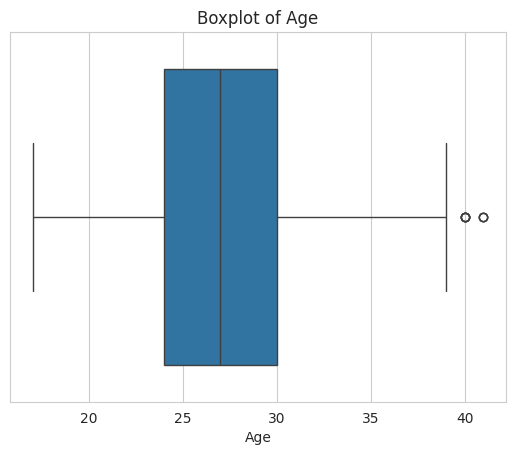

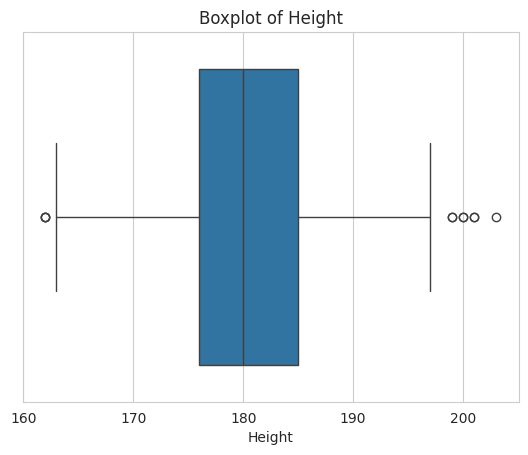

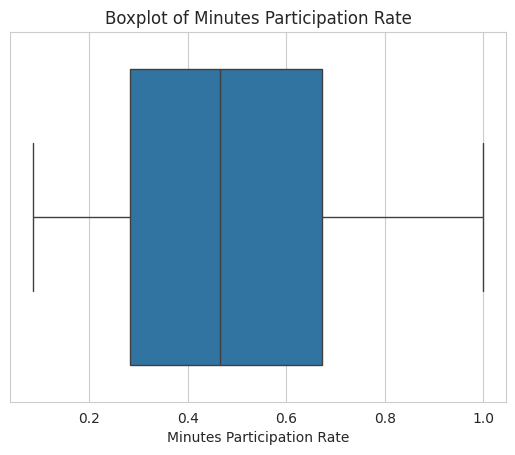

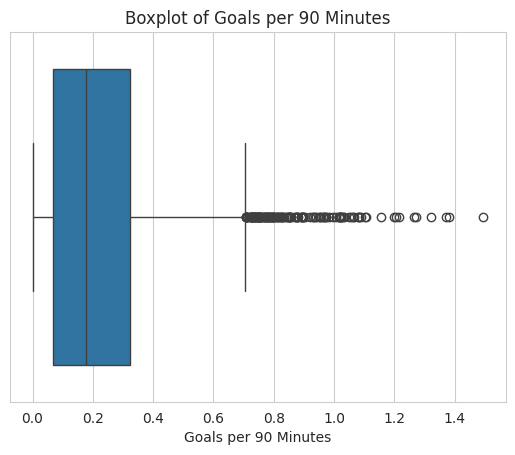

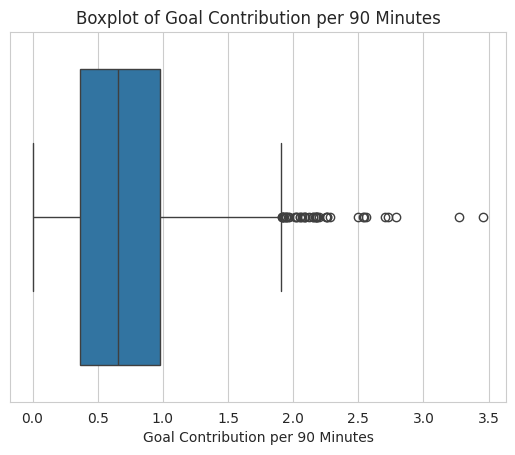

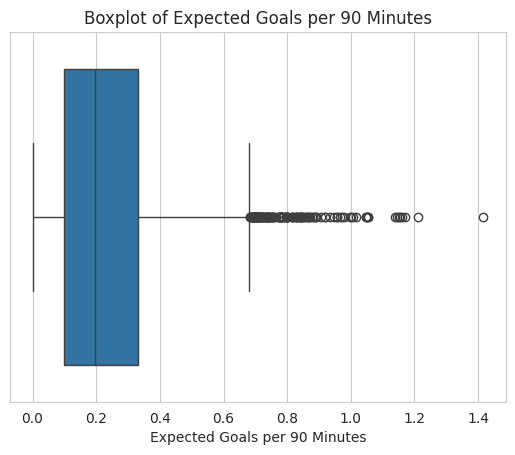

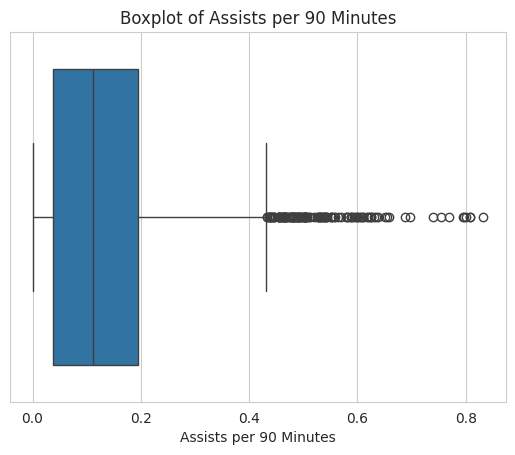

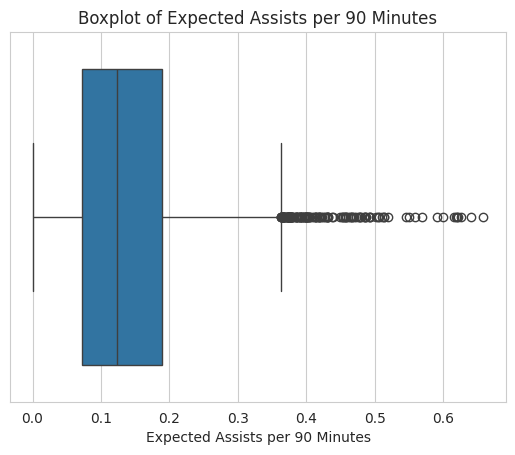

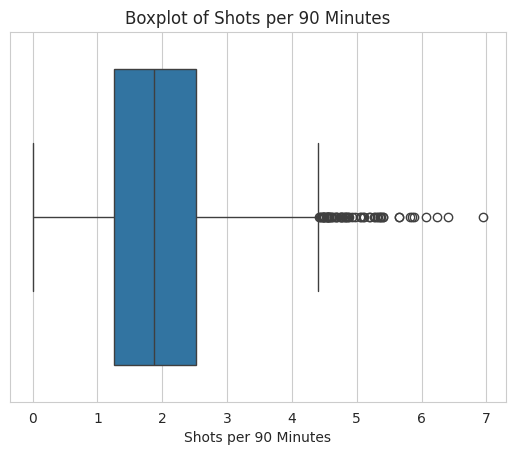

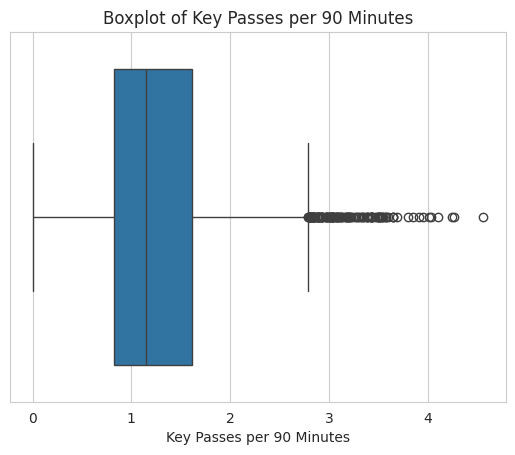

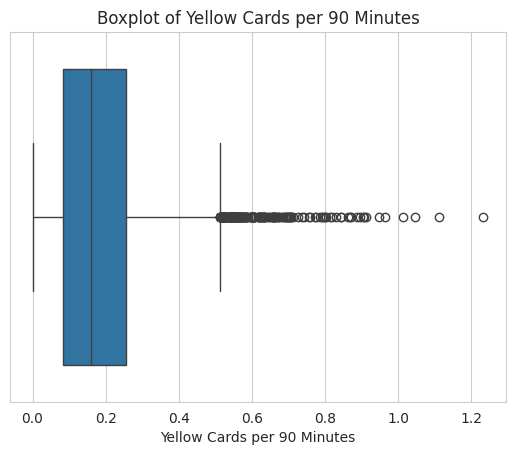

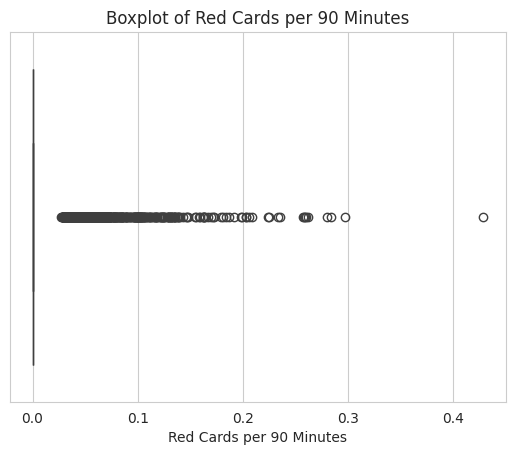

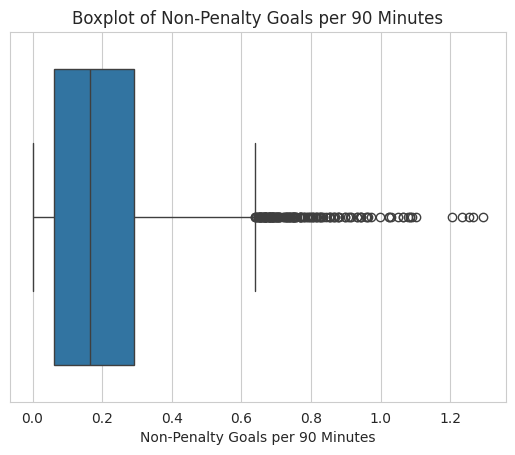

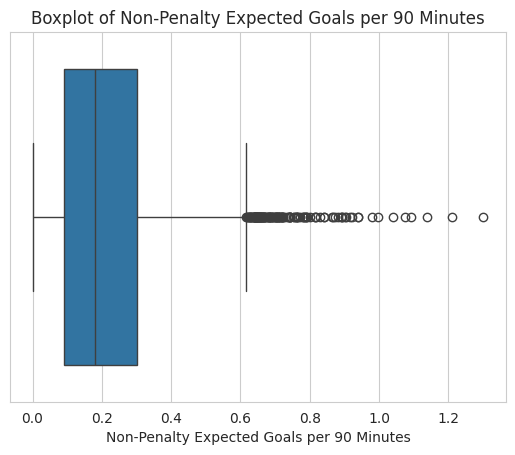

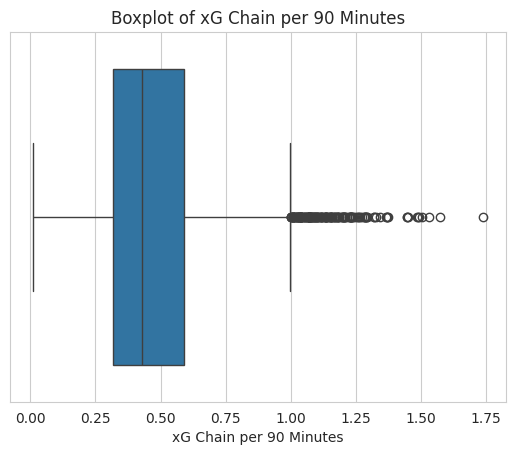

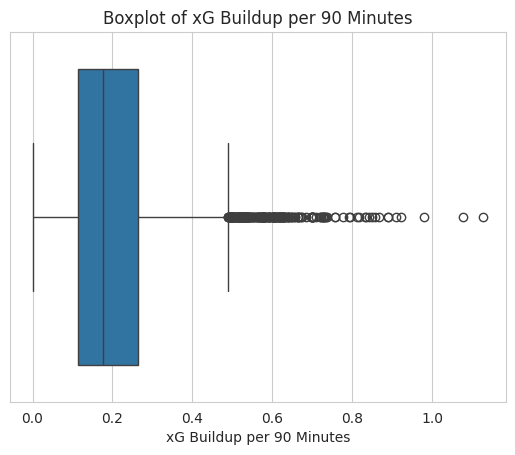

In [434]:
# Outliers - botplox
import matplotlib.pyplot as plt
import seaborn as sns

for column in numeric_columns:
    plt.figure()
    sns.boxplot(x=players[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

Position
CF    1611
CM    1547
RW     743
LW     718
AM     647
SS      80
LM      78
RM      70
Name: count, dtype: int64


<ipython-input-438-d57158f8a2e6>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=position_counts.index, y=position_counts.values, palette="Blues_r")


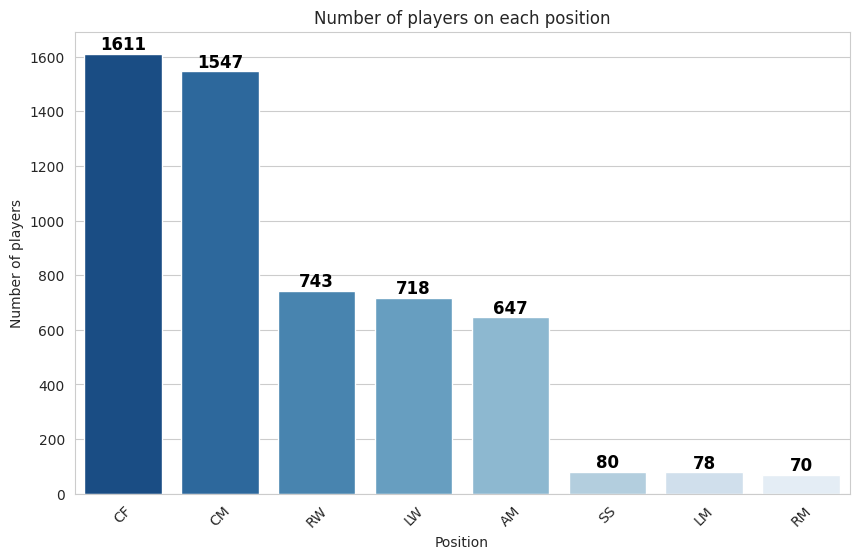

In [438]:
import matplotlib.pyplot as plt
import seaborn as sns

# Number of players on each position
position_counts = players["Position"].value_counts()

# Visualize the number of players in each position
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=position_counts.index, y=position_counts.values, palette="Blues_r")

# Add datalabels on top of bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

plt.xticks(rotation=45)
plt.xlabel("Position")
plt.ylabel("Number of players")
plt.title("Number of players on each position")
plt.show()

<ipython-input-439-e00bdef214cc>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=position_counts.index, y=position_counts.values, palette="Blues_r")


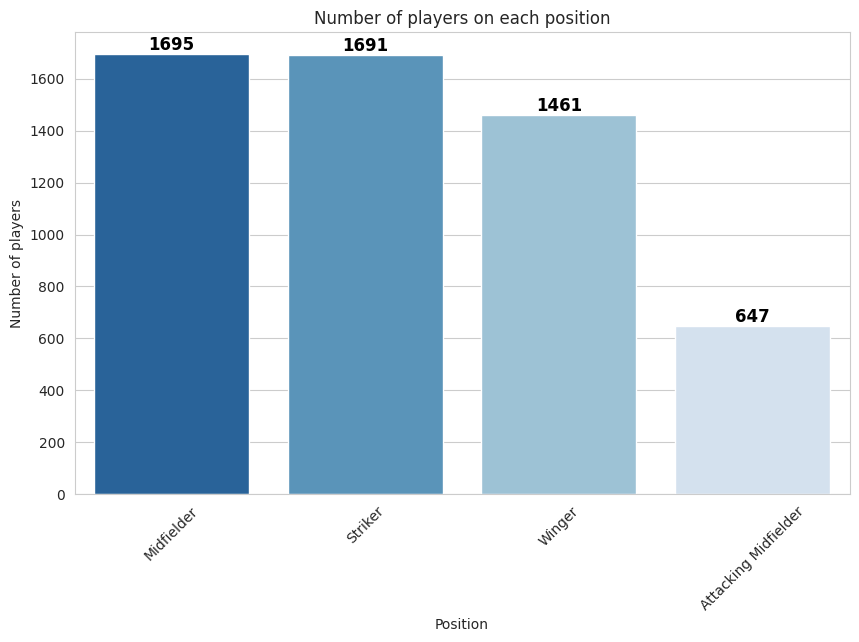

In [439]:
# Create new position groups
position_mapping = {"CF": "Striker",
    "SS": "Striker",
    "RW": "Winger",
    "LW": "Winger",
    "CM": "Midfielder",
    "LM": "Midfielder",
    "RM": "Midfielder",
    "AM": "Attacking Midfielder"}

players["Position"] = players["Position"].map(position_mapping)

# Visualize the number of new groups
position_counts = players["Position"].value_counts()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=position_counts.index, y=position_counts.values, palette="Blues_r")

# Add datalabels on top of bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

plt.xticks(rotation=45)
plt.xlabel("Position")
plt.ylabel("Number of players")
plt.title("Number of players on each position")
plt.show()

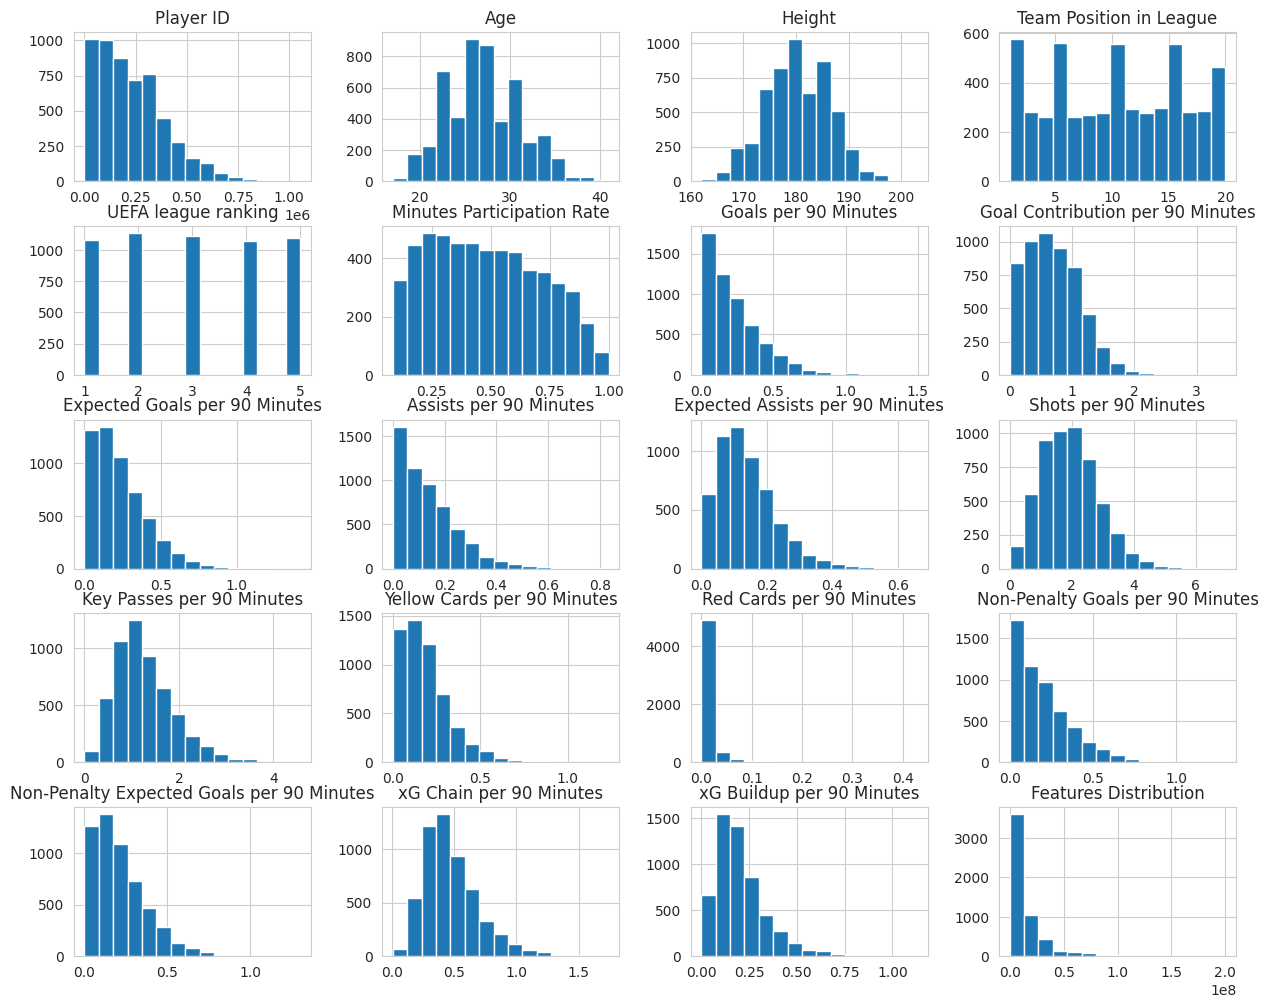

In [445]:
# Check the distribution of all numeric features
players.hist(figsize=(15,12),bins = 15)
plt.title("Features Distribution")
plt.show()

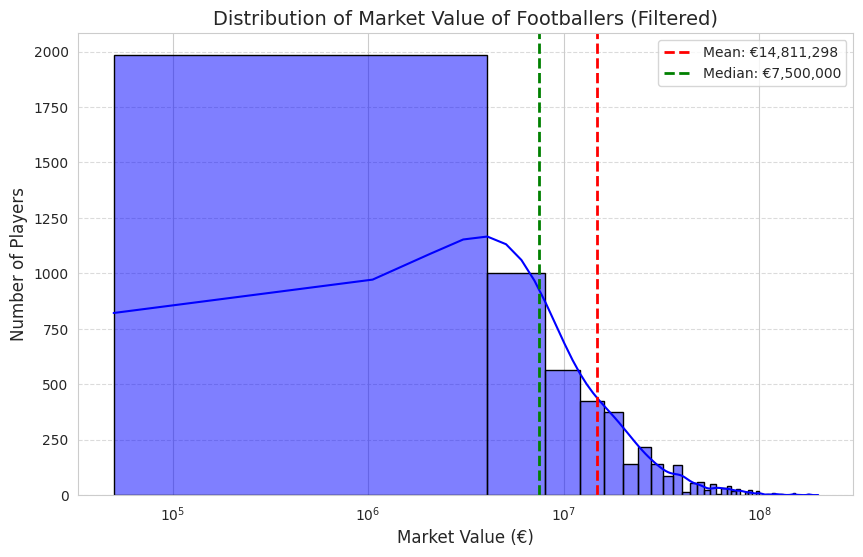

In [435]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate mean and median
mean_value = players["Market Value"].mean()
median_value = players["Market Value"].median()

# Set up the chart
plt.figure(figsize=(10, 6))
sns.histplot(players["Market Value"], bins=50, kde=True, color="blue", edgecolor="black")

# Add the mean and median lines
plt.axvline(mean_value, color="red", linestyle="dashed", linewidth=2, label=f"Mean: €{int(mean_value):,}")
plt.axvline(median_value, color="green", linestyle="dashed", linewidth=2, label=f"Median: €{int(median_value):,}")

# Logaritmic scale
plt.xscale("log")

# Axis descriptions and title
plt.xlabel("Market Value (€)", fontsize=12)
plt.ylabel("Number of Players", fontsize=12)
plt.title("Distribution of Market Value of Footballers (Filtered)", fontsize=14)

# Grid and legend
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# Show the chart
plt.show()